# CS224N Lecture 3 — A Worked Example: One Tiny Network, From Loss to Backprop

**Companion to:** Stanford CS224N, Lecture 3, *Backprop and Neural Networks* (Manning). Uses the lecture's notation: **column vectors**, $z = Wx + b$, $h = f(z)$, $s = u^\top h$.

### What this notebook does
Everything from the lecture in **one network small enough to compute by hand**, plus the piece that ties it together: **the loss function**.

| Part | What happens | You can check it by hand? |
|---|---|---|
| 1 | A 2-input network: **forward pass**, number by number | ✔ |
| 2 | **Losses**: binary cross-entropy, cross-entropy, why the **log**, softmax, perplexity | ✔ |
| 3 | **Jacobians**: the chain rule as matrix products, for our network | ✔ |
| 4 | **Backprop**: the error signal δ, reused for every gradient | ✔ |
| 5 | **Gradient check**: numbers vs. formulas | — |
| 6 | **Gradient descent**: watch the loss fall | — |
| 7 | The real thing, small: a **window classifier** for locations, word vectors included | — |
| 8 | Same in PyTorch (optional) | — |

**How to read it:** each code cell does one thing, and the important numbers are printed so you can follow along with a pencil. Run the cells in order.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)

---
## Part 1. The forward pass, by hand

The network (the lecture's window classifier, shrunk to 2 inputs and 2 hidden units):
$$z = Wx + b,\qquad h = f(z) = \text{ReLU}(z),\qquad s = u^\top h,\qquad p = \sigma(s) = \frac{1}{1 + e^{-s}}$$
* $x$: the input (in the lecture, the concatenated word vectors of a window)
* $W, b$: the hidden layer's weights and bias
* $f$: the **nonlinearity** (ReLU here: $\max(0, z)$)
* $s$: the **score** (any real number)
* $p$: the **probability** that the label is 1 ("the center word is a location")

The numbers, chosen so everything stays easy:
$$x = \begin{pmatrix}1\\2\end{pmatrix},\quad W = \begin{pmatrix}1 & 0\\-1 & 1\end{pmatrix},\quad b = \begin{pmatrix}0\\-0.5\end{pmatrix},\quad u = \begin{pmatrix}2\\3\end{pmatrix},\quad \text{true label } y = 0$$

In [2]:
x = np.array([1.0, 2.0])
W = np.array([[1.0, 0.0],
              [-1.0, 1.0]])
b = np.array([0.0, -0.5])
u = np.array([2.0, 3.0])
y = 0                                    # the true label: this example is NOT a location

relu = lambda z: np.maximum(0, z)
sigmoid = lambda s: 1 / (1 + np.exp(-s))

z = W @ x + b          # row 1: 1*1 + 0*2 + 0 = 1;   row 2: -1*1 + 1*2 - 0.5 = 0.5
h = relu(z)            # both positive, so unchanged
s = u @ h              # 2*1 + 3*0.5
p = sigmoid(s)
print("z = Wx + b =", z)
print("h = ReLU(z) =", h)
print("s = u.h    =", s)
print(f"p = sigmoid(s) = {p:.4f}   <- the network is 97% sure it's a location... but y = 0")

z = Wx + b = [1.  0.5]
h = ReLU(z) = [1.  0.5]
s = u.h    = 3.5
p = sigmoid(s) = 0.9707   <- the network is 97% sure it's a location... but y = 0


**Why the nonlinearity is there.** Without $f$, the score would be $s = u^\top(Wx + b)$, which is just another linear function of $x$; extra layers would add nothing. Check: with ReLU removed, the whole network equals a single vector $w' = W^\top u$:

In [ ]:
s_linear = u @ (W @ x + b)                      # the network without f
w_eq, b_eq = W.T @ u, u @ b                     # one equivalent linear model
print(f"without the nonlinearity: s = {s_linear}  == w'.x + b' = {w_eq @ x + b_eq}   with w' = {w_eq}")

---
## Part 2. The loss: how wrong is the network?

Training needs **one number** that measures how bad the prediction is, so we can push it down. That's the **loss** $J$.

### 2.1 Binary cross-entropy (BCE)
For a yes/no label $y\in\{0, 1\}$ and predicted probability $p = P(y = 1)$:
$$J = -\big[\,y\log p + (1 - y)\log(1 - p)\,\big]$$
Only one term is ever "on":
* if $y = 1$: $J = -\log p$ (punish a small $p$)
* if $y = 0$: $J = -\log(1 - p)$ (punish a large $p$)

In words: **the negative log of the probability the model gave to the right answer.** For our example ($y = 0$, $p = 0.9707$):

In [3]:
def bce(p, y):
    # Binary cross-entropy for probability p and label y in {0, 1}.
    return -(y * np.log(p) + (1 - y) * np.log(1 - p))

J = bce(p, y)
print(f"J = -log(1 - p) = -log({1 - p:.4f}) = {J:.4f}")

J = -log(1 - p) = -log(0.0293) = 3.5298


**How the loss behaves.** Probability given to the correct answer vs. loss:

probability on the right answer 0.99   : loss -log(q) =   0.010
probability on the right answer 0.9    : loss -log(q) =   0.105
probability on the right answer 0.5    : loss -log(q) =   0.693
probability on the right answer 0.1    : loss -log(q) =   2.303
probability on the right answer 0.01   : loss -log(q) =   4.605
probability on the right answer 0.0001 : loss -log(q) =   9.210


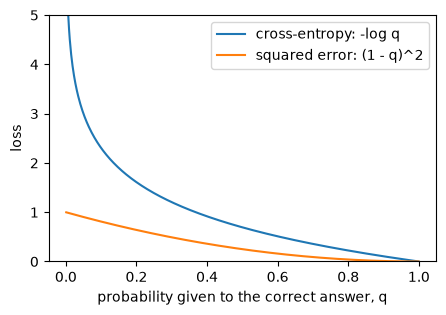

In [4]:
for q in [0.99, 0.9, 0.5, 0.1, 0.01, 0.0001]:
    print(f"probability on the right answer {q:<7}: loss -log(q) = {-np.log(q):7.3f}")

qs = np.linspace(0.001, 0.999, 500)
plt.figure(figsize=(5, 3.2)); plt.plot(qs, -np.log(qs), label="cross-entropy: -log q"); plt.plot(qs, (1 - qs) ** 2, label="squared error: (1 - q)^2")
plt.xlabel("probability given to the correct answer, q"); plt.ylabel("loss"); plt.legend(); plt.ylim(0, 5); plt.show()

### 2.2 Why the log? Four reasons

**Reason 1: it comes from maximum likelihood.** We want parameters that make the training labels as **probable** as possible. For $N$ independent examples, the probability of all the labels is a **product**:
$$L(\theta) = \prod_{i=1}^Np_\theta(y_i\mid x_i)$$
Taking the log turns the product into a **sum**, and maximizing the log is the same as maximizing the product (log is increasing). Flip the sign to get something to *minimize*:
$$J(\theta) = -\frac1N\sum_{i=1}^N\log p_\theta(y_i\mid x_i)$$
**Cross-entropy loss = average negative log-likelihood.** Same thing, two names.

**Reason 2: products of probabilities underflow.** Multiply 2,000 probabilities of 0.5 and the computer rounds it to zero; the sum of logs is fine:

In [5]:
probs = np.full(2000, 0.5)
print("product of 2000 probabilities of 0.5:", np.prod(probs), " <- underflowed to 0: useless for training")
print("sum of their logs:                   ", np.sum(np.log(probs)), " <- a perfectly normal number")

product of 2000 probabilities of 0.5: 0.0  <- underflowed to 0: useless for training
sum of their logs:                    -1386.2943611198907  <- a perfectly normal number


**Reason 3: confident mistakes cost a lot.** As $q\to0$, $-\log q\to\infty$. Squared error tops out at 1 however wrong you are (see the plot), so it barely punishes "99.99% sure and wrong".

**Reason 4 (the big one for training): the gradient doesn't vanish.** With a sigmoid output, the gradient of BCE with respect to the score is beautifully simple (derived in Part 4):
$$\frac{\partial J}{\partial s} = p - y$$
For squared error $(p - y)^2$, the chain rule adds a factor $\sigma'(s) = p(1 - p)$, which is nearly 0 when the sigmoid is saturated. So **when the model is confidently wrong, squared error gives almost no gradient**, exactly when it needs the most. The log cancels the sigmoid's flatness. Numbers, for a badly wrong score ($y = 1$, $s = -5$):

In [7]:
s_bad, y_bad = -5.0, 1
p_bad = sigmoid(s_bad)
grad_bce = p_bad - y_bad                                     # d/ds of BCE     
grad_mse = 2 * (p_bad - y_bad) * p_bad * (1 - p_bad)         # d/ds of (p - y)^2
print(f"p = {p_bad:.4f} (confidently wrong)")
print(f"gradient wrt the score: BCE {grad_bce:+.4f},  squared error {grad_mse:+.4f}  ({abs(grad_bce / grad_mse):.0f}x smaller)")

p = 0.0067 (confidently wrong)
gradient wrt the score: BCE -0.9933,  squared error -0.0132  (75x smaller)


**And in training:** one weight, one example, starting badly wrong. Count the gradient-descent steps until $p > 0.9$:

In [8]:
def steps_to_learn(loss_grad, w=-5.0, lr=1.0, x_in=1.0, max_steps=10000):
    # Gradient descent on one weight (score s = w * x_in, label 1) until sigmoid(s) > 0.9.
    for step in range(max_steps):
        p_ = sigmoid(w * x_in)
        if p_ > 0.9:
            return step
        w -= lr * loss_grad(p_) * x_in
    return max_steps

print("BCE:          ", steps_to_learn(lambda p_: p_ - 1), "steps")
print("squared error:", steps_to_learn(lambda p_: 2 * (p_ - 1) * p_ * (1 - p_)), "steps")

BCE:           16 steps
squared error: 119 steps


### 2.3 More than two classes: softmax + cross-entropy
With $C$ classes, the network outputs $C$ scores (**logits**) $s_1, \dots, s_C$. **Softmax** turns them into probabilities: exponentiate (all positive), then normalize (sum to 1):
$$\hat y_c = \frac{e^{s_c}}{\sum_ke^{s_k}},\qquad J = -\log\hat y_{\text{correct}}$$
**Its gradient is the same pattern:** $\frac{\partial J}{\partial s} = \hat y - y$ (predicted probabilities minus the one-hot target). By hand for scores (2, 1, 0) with class 0 correct:

In [ ]:
scores = np.array([2.0, 1.0, 0.0]); target = np.array([1.0, 0.0, 0.0])
exps = np.exp(scores)
y_hat = exps / exps.sum()
print("exponentiate:", exps.round(3), " sum", exps.sum().round(3))
print("softmax     :", y_hat.round(4))
print(f"loss = -log({y_hat[0]:.4f}) = {-np.log(y_hat[0]):.4f}")
print("gradient y_hat - y =", (y_hat - target).round(4), " <- push the correct score up, the others down")

**BCE is the 2-class case.** A sigmoid is a 2-class softmax with one score fixed at 0: $\frac{e^{s}}{e^{s} + e^{0}} = \sigma(s)$.

In [ ]:
s_test = 1.7
print(f"softmax([s, 0])[0] = {np.exp(s_test) / (np.exp(s_test) + 1):.6f}   sigmoid(s) = {sigmoid(s_test):.6f}")

### 2.4 Where the name comes from: information theory
For a true distribution $P$ and a predicted distribution $Q$:
$$\text{cross-entropy } H(P, Q) = -\sum_cP(c)\log Q(c),\qquad\text{entropy } H(P) = -\sum_cP(c)\log P(c),\qquad H(P, Q) = H(P) + \text{KL}(P\,\|\,Q)$$
* **Entropy** is the unavoidable uncertainty in $P$ itself.
* **KL divergence** is the *extra* cost of using $Q$ when the truth is $P$; it's 0 only when $Q = P$.
* With a one-hot target, $H(P) = 0$, so **cross-entropy = KL = $-\log Q(\text{correct})$**: the same loss as above.

With natural logs the unit is **nats**; with $\log_2$, **bits** (a fair coin flip has entropy 1 bit = $\log 2\approx0.693$ nats).

In [ ]:
P = target; Q = y_hat
H_P = -np.sum(P[P > 0] * np.log(P[P > 0]))
CE = -np.sum(P * np.log(Q))
KL = np.sum(P[P > 0] * np.log(P[P > 0] / Q[P > 0]))
print(f"one-hot target: H(P) = {abs(H_P):.4f}, KL = {KL:.4f}, cross-entropy = {CE:.4f}  (= H + KL)")
P_soft = np.array([0.7, 0.2, 0.1])                        # a "soft" target, as in label smoothing / distillation
print(f"soft target:    H(P) = {-np.sum(P_soft * np.log(P_soft)):.4f}, KL = {np.sum(P_soft * np.log(P_soft / Q)):.4f}, "
      f"cross-entropy = {-np.sum(P_soft * np.log(Q)):.4f}")

### 2.5 Three practical facts you'll meet again
**(a) Sanity-check the starting loss.** An untrained model guesses uniformly, so the loss should start near $\log C$ ($\log 2 = 0.693$ for binary). Much higher means a bug.

**(b) Perplexity** (used for language models from CS224N Lecture 5 on) is just the exponentiated average cross-entropy: $\text{PPL} = e^{J}$. It's the "effective number of choices" the model is torn between: a uniform guess over 10 words has $J = \log10$, perplexity 10.

In [ ]:
for C in [2, 10, 50000]:
    print(f"uniform guess over {C:>6} classes: starting loss log C = {np.log(C):7.3f},  perplexity = {np.exp(np.log(C)):,.0f}")

**(c) Compute the loss from the score, not the probability.** For a very wrong, very confident model, $\sigma(s)$ rounds to exactly 1.0 and $\log(1 - p) = \log0 = -\infty$. Rewrite the loss in terms of $s$ (algebra: $-\log\sigma(s) = \log(1 + e^{-s})$) and compute it stably. That's why PyTorch has `BCEWithLogitsLoss` (takes the score) instead of `BCELoss` (takes the probability), and why `CrossEntropyLoss` takes logits.

In [14]:
def bce_from_score(s_, y_):
    # Stable BCE computed from the score: y*log(1+e^-s) + (1-y)*log(1+e^s), via logaddexp.
    return y_ * np.logaddexp(0, -s_) + (1 - y_) * np.logaddexp(0, s_)

s_huge = 40.0
with np.errstate(divide="ignore"):
    print(f"s = {s_huge}, y = 0:  from the probability: {bce(sigmoid(s_huge), 0)}   from the score: {bce_from_score(s_huge, 0):.4f}")
print(f"our example (s = 3.5, y = 0): both give {bce(p, 0):.4f} = {bce_from_score(s, 0):.4f}")

s = 40.0, y = 0:  from the probability: inf   from the score: 40.0000
our example (s = 3.5, y = 0): both give 3.5298 = 3.5298


🔎 **An older alternative from CS224N:** earlier years of this lecture used a **max-margin (hinge) loss** for the window classifier: make the true window's score at least 1 higher than a corrupted window's, $J = \max(0, 1 - s + s_c)$. It has no probabilities and no log, and it stops pushing once the margin is met. Cross-entropy became the standard because it gives probabilities and keeps improving confident predictions.

---
## Part 3. Jacobians: the chain rule as matrix products

**The Jacobian** of $f:\mathbb{R}^n\to\mathbb{R}^m$ is the $m\times n$ matrix of all partial derivatives, $\left(\frac{\partial f}{\partial x}\right)_{ij} = \frac{\partial f_i}{\partial x_j}$: row $i$ says how output $i$ responds to each input. **The chain rule = multiplying Jacobians.**

Our network is a chain $b\to z\to h\to s\to J$. The Jacobian of each link:

| Link | Jacobian | Why |
|---|---|---|
| $J$ w.r.t. $s$ | $p - y$ (1×1) | BCE + sigmoid (Part 4 derives it) |
| $s = u^\top h$ w.r.t. $h$ | $u^\top$ (1×2) | $\partial s/\partial h_j = u_j$ |
| $h = f(z)$ w.r.t. $z$ | $\text{diag}(f'(z))$ (2×2) | each $h_i$ depends only on $z_i$ |
| $z = Wx + b$ w.r.t. $b$ | $I$ (2×2) | $z_i = \dots + b_i$ |
| $z = Wx + b$ w.r.t. $x$ | $W$ (2×2) | $\partial z_i/\partial x_j = W_{ij}$ |

Each link as an actual matrix:

In [15]:
f_prime = (z > 0).astype(float)                     # ReLU' = 1 where z > 0
J_s   = np.array([[p - y]])                         # dJ/ds        (1 x 1)
J_h   = u.reshape(1, 2)                             # ds/dh = u^T  (1 x 2)
J_z   = np.diag(f_prime)                            # dh/dz        (2 x 2), diagonal
J_b   = np.eye(2)                                   # dz/db        (2 x 2)
J_x   = W                                           # dz/dx        (2 x 2)
print("dJ/ds =", J_s, "\nds/dh =", J_h, "\ndh/dz =\n", J_z, "\ndz/db =\n", J_b)

dJ/ds = [[0.9707]] 
ds/dh = [[2. 3.]] 
dh/dz =
 [[1. 0.]
 [0. 1.]] 
dz/db =
 [[1. 0.]
 [0. 1.]]


**Multiply along the chain** to get the gradient for $b$ and for $x$:
$$\frac{\partial J}{\partial b} = \frac{\partial J}{\partial s}\,\frac{\partial s}{\partial h}\,\frac{\partial h}{\partial z}\,\frac{\partial z}{\partial b},\qquad\frac{\partial J}{\partial x} = \frac{\partial J}{\partial s}\,\frac{\partial s}{\partial h}\,\frac{\partial h}{\partial z}\,\frac{\partial z}{\partial x}$$

In [16]:
dJ_db_jacobian = J_s @ J_h @ J_z @ J_b              # (1x1)(1x2)(2x2)(2x2) = 1 x 2
dJ_dx_jacobian = J_s @ J_h @ J_z @ J_x
print("dJ/db =", dJ_db_jacobian)
print("dJ/dx =", dJ_dx_jacobian)

dJ/db = [[1.9414 2.9121]]
dJ/dx = [[-0.9707  2.9121]]


**Notice:** both products start with the **same three factors**, $\frac{\partial J}{\partial s}\frac{\partial s}{\partial h}\frac{\partial h}{\partial z}$. Computing that shared part once and reusing it *is* backpropagation (Part 4).

**Shape convention vs. Jacobian form.** The Jacobian results above are **row** vectors (1×2), but $b$ and $x$ are column vectors. For gradient descent we want the gradient **in the same shape as the parameter** (the *shape convention*), so we transpose at the end. For a matrix $W$ (2×2) the pure Jacobian $\partial J/\partial W$ would be a 1×4 row, which is awkward; the shape convention gives a 2×2 matrix instead (Part 4).

**Never build diagonal Jacobians in real code:** multiplying by $\text{diag}(f'(z))$ is just elementwise multiplication by $f'(z)$ (written $\odot$):

In [17]:
v = np.array([5.0, -7.0])
print("v @ diag(f'(z)) =", v @ J_z, "   v * f'(z) =", v * f_prime, " <- the same, no matrix needed")

v @ diag(f'(z)) = [ 5. -7.]    v * f'(z) = [ 5. -7.]  <- the same, no matrix needed


---
## Part 4. Backprop: compute δ once, reuse it everywhere

**Step 1: the gradient at the top**, $\partial J/\partial s$. For BCE with $p = \sigma(s)$, using $\sigma'(s) = \sigma(s)(1 - \sigma(s))$:
$$y = 1:\ \frac{\partial}{\partial s}\big[-\log\sigma(s)\big] = -\frac{\sigma(s)(1 - \sigma(s))}{\sigma(s)} = p - 1,\qquad y = 0:\ \frac{\partial}{\partial s}\big[-\log(1 - \sigma(s))\big] = \frac{\sigma(s)(1 - \sigma(s))}{1 - \sigma(s)} = p$$
Both are $p - y$. **The log cancels the sigmoid's derivative**, which is Reason 4 from Part 2.

**Step 2: the error signal.** Manning's **local error signal** is the gradient arriving at $z$:
$$\delta = \frac{\partial J}{\partial z} = (p - y)\,u\odot f'(z)$$

**Step 3: every other gradient reuses δ** (shape convention):
$$\frac{\partial J}{\partial b} = \delta,\qquad\frac{\partial J}{\partial W} = \delta\,x^\top\ \text{(outer product, same shape as W)},\qquad\frac{\partial J}{\partial x} = W^\top\delta,\qquad\frac{\partial J}{\partial u} = (p - y)\,h$$
Each gradient is the **upstream gradient times a local gradient**.

**Dimension check:** $W$ is 2×2, $\delta$ is 2×1, $x$ is 2×1. Only $\delta x^\top$ (2×1 times 1×2) gives 2×2, so it must be right.

In [18]:
dJ_ds = p - y                                   # top of the chain
delta = dJ_ds * u * f_prime                     # local error signal at z
dJ_db = delta
dJ_dW = np.outer(delta, x)                      # delta x^T
dJ_dx = W.T @ delta
dJ_du = dJ_ds * h
print(f"dJ/ds = p - y = {dJ_ds:.4f}")
print("delta = (p - y) u * f'(z) =", delta)
print("dJ/db =", dJ_db, "  (matches the Jacobian result, transposed)")
print("dJ/dW = delta x^T =\n", dJ_dW)
print("dJ/dx = W^T delta =", dJ_dx, "  (matches)")
print("dJ/du = (p - y) h =", dJ_du)

dJ/ds = p - y = 0.9707
delta = (p - y) u * f'(z) = [1.9414 2.9121]
dJ/db = [1.9414 2.9121]   (matches the Jacobian result, transposed)
dJ/dW = delta x^T =
 [[1.9414 3.8828]
 [2.9121 5.8241]]
dJ/dx = W^T delta = [-0.9707  2.9121]   (matches)
dJ/du = (p - y) h = [0.9707 0.4853]


**By hand for $\partial J/\partial W$:** $\delta = 0.9707\times(2, 3)\odot(1, 1) = (1.941, 2.912)$, so
$$\delta x^\top = \begin{pmatrix}1.941\\2.912\end{pmatrix}\begin{pmatrix}1 & 2\end{pmatrix} = \begin{pmatrix}1.941 & 3.883\\2.912 & 5.824\end{pmatrix}$$
**Reading it:** $\partial J/\partial W_{ij} = \delta_i\,x_j$: (how much hidden unit $i$'s input matters) × (how big input $j$ was). Weights connected to large inputs and important units get the largest gradients.

**Why $\partial J/\partial x$ matters:** in the window classifier, $x$ **is** the word vectors, so this gradient updates the **word embeddings** themselves.

---
## Part 5. Gradient check: do the formulas match the numbers?

Nudge each parameter by $\pm\epsilon$ and measure how the loss changes:
$$\frac{\partial J}{\partial\theta}\approx\frac{J(\theta + \epsilon) - J(\theta - \epsilon)}{2\epsilon}$$
Too slow for training (two forward passes **per parameter**), but the standard way to catch bugs in hand-written gradients.

In [19]:
def loss_fn(W_, b_, u_, x_):
    # The full forward pass, returning the BCE loss (computed stably from the score).
    return bce_from_score(u_ @ relu(W_ @ x_ + b_), y)

def numerical_grad(param, eps=1e-6):
    # Nudge each entry of `param` (in place, then restore) and measure the change in loss.
    g = np.zeros_like(param)
    for idx in np.ndindex(param.shape):
        old = param[idx]
        param[idx] = old + eps; plus = loss_fn(W, b, u, x)
        param[idx] = old - eps; minus = loss_fn(W, b, u, x)
        param[idx] = old
        g[idx] = (plus - minus) / (2 * eps)
    return g

for name, param, analytic in [("W", W, dJ_dW), ("b", b, dJ_db), ("u", u, dJ_du), ("x", x, dJ_dx)]:
    num = numerical_grad(param)
    print(f"dJ/d{name}: max |formula - numerical| = {np.abs(num - analytic).max():.1e}")

dJ/dW: max |formula - numerical| = 3.4e-07
dJ/db: max |formula - numerical| = 1.7e-07
dJ/du: max |formula - numerical| = 1.0e-06
dJ/dx: max |formula - numerical| = 1.7e-07


---
## Part 6. Gradient descent: take steps downhill

$$\theta\leftarrow\theta - \alpha\,\frac{\partial J}{\partial\theta}$$
We move **against** the gradient (it points uphill). This tiny example also shows two classic things that can go wrong: **dead ReLUs**, and why networks have **bias** terms.

### 6.1 One step
One step with $\alpha = 0.1$, on $W$, $b$, $u$ (keeping $x$ fixed for now):

In [20]:
def forward_backward(W_, b_, u_, x_, y_, c_=0.0):
    # One full forward and backward pass (c_ = optional output bias, used in 6.3).
    # Returns the loss and the gradients (shape convention).
    z_ = W_ @ x_ + b_; h_ = relu(z_); s_ = u_ @ h_ + c_; p_ = sigmoid(s_)
    d_s = p_ - y_
    delta_ = d_s * u_ * (z_ > 0)
    return bce_from_score(s_, y_), {"W": np.outer(delta_, x_), "b": delta_, "u": d_s * h_, "x": W_.T @ delta_, "c": d_s}

lr = 0.1
J_before, g = forward_backward(W, b, u, x, y)
W_new, b_new, u_new = W - lr * g["W"], b - lr * g["b"], u - lr * g["u"]
J_after, g_after = forward_backward(W_new, b_new, u_new, x, y)
print(f"loss before the step {J_before:.4f} -> after one step {J_after:.4f}   (log 2 = {np.log(2):.4f})")
print("z after the step:", (W_new @ x + b_new).round(3))

loss before the step 3.5298 -> after one step 0.6931   (log 2 = 0.6931)
z after the step: [-0.165 -1.247]


The loss dropped a lot, to exactly $\log 2$. But look at $z$: **both entries are now negative**, so both ReLUs output 0, the score is $s = 0$, and $p = 0.5$.

### 6.2 Keep going… and get stuck
Every gradient flows through $f'(z)$, which is now 0 for both units, so **every gradient is exactly zero**. No later step can change anything:

In [21]:
print("gradients after the step:", {k: np.round(v, 6) for k, v in g_after.items() if k != "c"})
W_t, b_t, u_t = W_new.copy(), b_new.copy(), u_new.copy()
for step in range(100):
    J_t, g = forward_backward(W_t, b_t, u_t, x, y)
    W_t -= lr * g["W"]; b_t -= lr * g["b"]; u_t -= lr * g["u"]
print(f"after 100 more steps: loss {J_t:.4f}  (stuck at log 2: the network is 'dead')")

gradients after the step: {'W': array([[0., 0.],
       [0., 0.]]), 'b': array([0., 0.]), 'u': array([0., 0.]), 'x': array([0., 0.])}
after 100 more steps: loss 0.6931  (stuck at log 2: the network is 'dead')


**Is the learning rate to blame? Partly, but not only.** Smaller steps reach the same dead end, just more slowly:

In [22]:
for lr_try in [0.01, 0.02, 0.05]:
    W_t, b_t, u_t = W.copy(), b.copy(), u.copy()
    for step in range(100):
        J_t, g = forward_backward(W_t, b_t, u_t, x, y)
        W_t -= lr_try * g["W"]; b_t -= lr_try * g["b"]; u_t -= lr_try * g["u"]
    print(f"lr {lr_try}: loss after 100 steps {J_t:.4f},  z = {(W_t @ x + b_t).round(3)}")

lr 0.01: loss after 100 steps 0.6931,  z = [-0.024 -0.002]
lr 0.02: loss after 100 steps 0.6931,  z = [-0.046 -0.164]
lr 0.05: loss after 100 steps 0.6931,  z = [-0.282 -0.374]


**Why it happens.** The label is $y = 0$, so the loss wants a **negative** score. But ReLU outputs are never negative ($h\geq0$) and $s = u^\top h$ has no bias, so the cheapest way for gradient descent to shrink $s$ is to **push $z$ below zero and switch the units off**. Once off, $s$ is stuck at 0 and the gradient is zero forever: **dead ReLUs**.

### 6.3 The fix: an output bias
Add one parameter, $s = u^\top h + c$. Its gradient is the simplest of all: $\frac{\partial J}{\partial c} = \frac{\partial J}{\partial s}\cdot\frac{\partial s}{\partial c} = (p - y)\cdot1$. Now the network can lower the score directly:

with an output bias: loss 3.530 -> 0.1066;  P(y = 0): 0.029 -> 0.900;  c = -2.195
z at the end: [-0.165 -1.247]


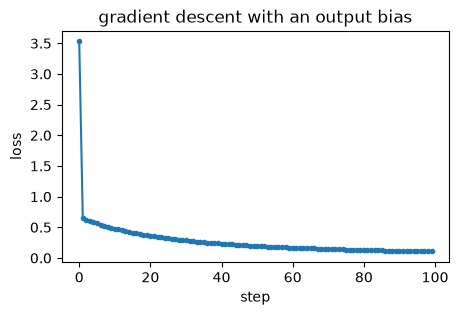

In [23]:
W_t, b_t, u_t, c_t = W.copy(), b.copy(), u.copy(), 0.0
history = []
for step in range(100):
    J_t, g = forward_backward(W_t, b_t, u_t, x, y, c_t)
    history.append(J_t)
    W_t -= lr * g["W"]; b_t -= lr * g["b"]; u_t -= lr * g["u"]; c_t -= lr * g["c"]
p_final = sigmoid(u_t @ relu(W_t @ x + b_t) + c_t)
print(f"with an output bias: loss {history[0]:.3f} -> {history[-1]:.4f};  P(y = 0): {1 - p:.3f} -> {1 - p_final:.3f};  c = {c_t:.3f}")
print("z at the end:", (W_t @ x + b_t).round(3))
plt.figure(figsize=(5, 3)); plt.plot(history, "o-", ms=3); plt.xlabel("step"); plt.ylabel("loss"); plt.title("gradient descent with an output bias"); plt.show()

**What to notice:**
* The loss now keeps falling past $\log 2$: the bias $c$ goes negative and carries the prediction toward $y = 0$.
* The hidden units still switched off. For **one** example of class 0, "turn everything off and use the bias" really is a solution. With many examples of **both** classes (Part 7), the units are needed and stay alive.
* The steps shrink as the loss falls, because the gradient $p - y$ shrinks as the prediction improves.

**Lessons:**
* **Too big a step can kill units in one move.**
* **Biases matter.**
* **Dead ReLUs are real.** Leaky ReLU, which keeps a small slope for $z < 0$, is one fix (Exercise 1).

---
## Part 7. The real thing, small: a window classifier for locations

Now the lecture's actual model, at toy size. **Task:** is the center word of a 3-word window a **location**?
* Each word has a **word vector** (dimension $d = 4$), stored as a row of an embedding matrix $E$.
* A window "in paris are" becomes $x = [e_{\text{in}}; e_{\text{paris}}; e_{\text{are}}]$ (12 numbers).
* Then exactly Parts 1–6: $z = Wx + b$, $h = \text{ReLU}(z)$, $s = u^\top h$, $p = \sigma(s)$, BCE loss.
* **The word vectors are parameters too**: $\partial J/\partial x$ is split into three chunks, each added to its word's row of $E$.

**Step 1: the data.** Sentences with the location words marked; windows are padded with `<s>` and `</s>`.

In [24]:
locations = {"paris", "london", "tokyo", "rome"}
train_sentences = [
    "museums in paris are amazing", "i flew to london last week", "we live in tokyo now",
    "rome is beautiful in spring", "she moved to paris recently", "the museum in london is free",
    "my friend is very nice", "the food is amazing here", "we flew home last week", "he is in the kitchen",
    "they went to the park", "trains to rome are slow",
]
vocab = ["<s>", "</s>", "<unk>"] + sorted({w for sent in train_sentences for w in sent.split()})
word_ix = {w: i for i, w in enumerate(vocab)}

def windows(sentence):
    # All (left, center, right) windows of a sentence as word indices, with labels (1 = location).
    words = ["<s>"] + sentence.split() + ["</s>"]
    out = []
    for i in range(1, len(words) - 1):
        ids = [word_ix.get(w, word_ix["<unk>"]) for w in words[i - 1:i + 2]]   # unseen words -> <unk>
        out.append((ids, int(words[i] in locations), words[i]))
    return out

train = [w for sent in train_sentences for w in windows(sent)]
print(f"vocabulary: {len(vocab)} words;  {len(train)} training windows, {sum(lab for _, lab, _ in train)} of them locations")
print("example window:", [vocab[i] for i in train[2][0]], "label", train[2][1])

vocabulary: 42 words;  62 training windows, 7 of them locations
example window: ['in', 'paris', 'are'] label 1


**Step 2: parameters.** Small random numbers (never all zeros: identical hidden units would stay identical forever).

In [ ]:
d, H = 4, 6                                         # word-vector size, hidden units
rng = np.random.default_rng(0)
params = {
    "E": rng.normal(0, 0.5, (len(vocab), d)),       # word vectors, one row per word
    "W": rng.normal(0, 0.5, (H, 3 * d)),            # hidden layer: 3 words x d numbers in
    "b": np.zeros(H),
    "u": rng.normal(0, 0.5, H),                     # hidden -> score
}
print({k: v.shape for k, v in params.items()})

**Step 3: forward and backward for one window.** The same formulas as Part 4, plus one new step at the end: route $\partial J/\partial x$ back to the three word vectors. If a word appears twice in a window, its two gradients **add** (the "branching sums gradients" rule).

In [ ]:
def window_forward_backward(params, ids, label):
    # Loss and gradients (shape convention) for one window. ids: 3 word indices.
    E, W_, b_, u_ = params["E"], params["W"], params["b"], params["u"]
    x_ = np.concatenate([E[i] for i in ids])        # look up and concatenate the 3 word vectors
    z_ = W_ @ x_ + b_
    h_ = relu(z_)
    s_ = u_ @ h_
    p_ = sigmoid(s_)
    loss = bce_from_score(s_, label)
    d_s = p_ - label                                # dJ/ds
    delta_ = d_s * u_ * (z_ > 0)                    # error signal at z
    grads = {"W": np.outer(delta_, x_), "b": delta_, "u": d_s * h_, "E": np.zeros_like(E)}
    dx = W_.T @ delta_                              # gradient for the concatenated input
    for k, i in enumerate(ids):
        grads["E"][i] += dx[k * d:(k + 1) * d]      # send each chunk to its word's vector (+=: repeats add)
    return loss, p_, grads

**Step 4: gradient check the whole model**, including the word vectors:

In [ ]:
ids, label, _ = train[1]                            # the window ("in", "paris", "are")
_, _, grads = window_forward_backward(params, ids, label)
worst = 0.0
for name in params:
    for _ in range(5):
        idx = (ids[rng.integers(3)], rng.integers(d)) if name == "E" else tuple(rng.integers(0, n) for n in params[name].shape)
        old = params[name][idx]
        params[name][idx] = old + 1e-6; plus = window_forward_backward(params, ids, label)[0]
        params[name][idx] = old - 1e-6; minus = window_forward_backward(params, ids, label)[0]
        params[name][idx] = old
        num = (plus - minus) / 2e-6
        worst = max(worst, abs(num - grads[name][idx]) / max(abs(num), abs(grads[name][idx]), 1e-10))
print(f"window classifier gradient check: max relative error {worst:.1e}")

**Step 5: train with SGD** (one window at a time, shuffled each epoch). The starting loss should be in the neighborhood of $\log2 = 0.693$ (Part 2.5's sanity check; random initial weights push it somewhat higher, but not to something like 10). This model has no output bias, but with many examples of both classes it doesn't get stuck like Part 6.

In [ ]:
def average_loss(params, data):
    return np.mean([window_forward_backward(params, ids, lab)[0] for ids, lab, _ in data])

print(f"starting average loss: {average_loss(params, train):.3f}   (log 2 = {np.log(2):.3f})")
lr = 0.05
losses = []
for epoch in range(150):
    for k in rng.permutation(len(train)):
        ids, label, _ = train[k]
        _, _, g = window_forward_backward(params, ids, label)
        for name in params:
            params[name] -= lr * g[name]            # gradient descent on EVERYTHING, word vectors included
    losses.append(average_loss(params, train))
print(f"average loss after training: {losses[-1]:.4f}")
plt.figure(figsize=(5, 3)); plt.plot(losses); plt.xlabel("epoch"); plt.ylabel("average loss"); plt.title("window classifier"); plt.show()

**Step 6: test on new sentences**, including **unseen** words ("berlin", "madrid"), which become `<unk>`: the model has to decide from the **context** alone.

In [ ]:
test_sentences = ["museums in berlin are great", "we flew to madrid last week", "trains to paris are fast",
                  "the food in rome is amazing", "my friend is in the park"]
for sent in test_sentences:
    words = sent.split()
    probs = [window_forward_backward(params, ids, lab)[1] for ids, lab, _ in windows(sent)]
    marked = " ".join(f"{w}[{pr:.2f}]" if pr > 0.5 else w for w, pr in zip(words, probs))
    print(f"{marked}")
print("\n(words marked [p] were predicted as locations, with p = P(location))")

**What to notice:** the model learned two kinds of evidence. **Word identity:** "paris", "rome" get high scores from their own word vectors. **Context:** a window with "in" or "to" on the left looks location-like, which is the only evidence available for `<unk>` words like "berlin". That's exactly why the lecture classifies **windows** rather than single words. Context alone could mislead ("in the park" has "in" on the left of "the"), but the training sentence "he is in the kitchen" taught the model that "the" after "in" is not a location.

**The word vectors moved during training.** Locations should now sit closer to each other than to other words (cosine similarity, 1 = same direction):

In [ ]:
def cosine(a, b_):
    return a @ b_ / (np.linalg.norm(a) * np.linalg.norm(b_))
E_ = params["E"]
for w1, w2 in [("paris", "london"), ("paris", "tokyo"), ("paris", "museum"), ("paris", "friend")]:
    print(f"cos({w1}, {w2}) = {cosine(E_[word_ix[w1]], E_[word_ix[w2]]):+.2f}")

---
## Part 8. The same in PyTorch (optional, run in Colab)

PyTorch builds the computation graph as the code runs and does all of Parts 3–4 for you with `.backward()`. Checking it reproduces our hand-computed numbers from Part 4:

In [ ]:
# [PyTorch] Needs: pip install torch
import torch
xt = torch.tensor([1.0, 2.0], requires_grad=True)
Wt = torch.tensor([[1.0, 0.0], [-1.0, 1.0]], requires_grad=True)
bt = torch.tensor([0.0, -0.5], requires_grad=True)
ut = torch.tensor([2.0, 3.0], requires_grad=True)
st = ut @ torch.relu(Wt @ xt + bt)                                       # the score (a logit)
loss = torch.nn.functional.binary_cross_entropy_with_logits(st, torch.tensor(0.0))   # stable BCE from the score
loss.backward()                                                          # backprop: fills every .grad
print("loss", loss.item())
print("dJ/dW =", Wt.grad, "\ndJ/db =", bt.grad, "\ndJ/du =", ut.grad, "\ndJ/dx =", xt.grad)

---
## Summary

| Idea | In our network |
|---|---|
| **Nonlinearity** | $h = \text{ReLU}(z)$; without it the whole network collapses to one linear function |
| **Loss** | BCE $= -[y\log p + (1-y)\log(1-p)]$: the negative log of the probability on the right answer |
| **Why log** | Maximum likelihood (products → sums); no underflow; confident mistakes cost a lot; the gradient $p - y$ doesn't vanish |
| **Softmax + CE** | $J = -\log\hat y_{\text{correct}}$, gradient $\hat y - y$; BCE is the 2-class case |
| **Cross-entropy** | $H(P, Q) = H(P) + \text{KL}(P\|Q)$; perplexity $= e^J$; start near $\log C$ |
| **Jacobian** | Matrix of partial derivatives; chain rule = multiply them; elementwise $f$ gives a diagonal one |
| **Backprop** | Compute $\delta = (p - y)\,u\odot f'(z)$ once; $\partial J/\partial b = \delta$, $\partial J/\partial W = \delta x^\top$, $\partial J/\partial x = W^\top\delta$ |
| **Shape convention** | Gradients have the parameter's shape; check dimensions to get the order right |
| **Gradient check** | $(J(\theta + \epsilon) - J(\theta - \epsilon))/2\epsilon$, to verify formulas |
| **Gradient descent** | $\theta\leftarrow\theta - \alpha\nabla J$, word vectors included |

### Check yourself
<details><summary>1. Our network gives p = 0.97 for an example with y = 0. What is the loss, and what is ∂J/∂s?</summary>

J = −log(1 − 0.97) ≈ 3.5, and ∂J/∂s = p − y = 0.97: a large push to lower the score.
</details>

<details><summary>2. Why does squared error train slowly when a sigmoid output is confidently wrong?</summary>

Its gradient with respect to the score contains σ′(s) = p(1 − p), which is nearly 0 when the sigmoid is saturated. Cross-entropy's log cancels that factor, leaving p − y.
</details>

<details><summary>3. What is the Jacobian of h = ReLU(z), and how do you use it without building it?</summary>

diag(f′(z)) with f′ = 1 where z > 0, else 0. Multiplying by it is the same as elementwise multiplication by f′(z).
</details>

<details><summary>4. W is 3×5. What shapes are δ, x, and ∂J/∂W, and in what order do δ and x multiply?</summary>

δ is 3×1, x is 5×1, ∂J/∂W is 3×5 = δ xᵀ (only that order gives 3×5).
</details>

<details><summary>5. An untrained 4-class classifier starts with loss 9.2. What do you suspect?</summary>

A bug or a bad initialization: a near-uniform guess should give about log 4 ≈ 1.39.
</details>

### Exercises
1. Change $f$ from ReLU to **Leaky ReLU** ($f(z) = \max(0.01z, z)$, $f'(z) = 0.01$ for $z < 0$) and rerun Part 6.2. Does the network still get stuck? Then try **tanh** ($f'(z) = 1 - \tanh^2(z)$).
2. Replace BCE with **squared error** in Part 7's training loop. How many epochs does it need to reach the same loss?
3. Make Part 7 a **3-class** problem (location / person / other) with softmax + cross-entropy. Only $u$ (now a matrix) and $\partial J/\partial s = \hat y - y$ change.
4. In Part 7, **freeze the word vectors** (don't update `E`). Does accuracy on the training windows change? On the test sentences?
5. Add **L2 regularization** $\lambda\sum W^2$ to the loss. What extra term appears in $\partial J/\partial W$?